## Linear Algebra

In physics, we rarely deal with just one variable. Whether you are finding the currents in a complex circuit or the vibrations of a molecule, you are dealing with "Systems". We use linear algebra to solve these the components of a system all at once.

### Static Systems: $Ax = b$

In your Math Physics or Statics classes, you encounter problems where you have multiple unknown values tied together by several equations.

Examples: Kirchhoff’s Laws (Circuits) or Force Balance (Trusses).
e.g. You have 3 loops in a circuit. You need to find 3 currents ($I_1, I_2, I_3$).

In matrix Form:


$$\begin{bmatrix} R_{11} & R_{12} & R_{13} \\ R_{21} & R_{22} & R_{23} \\ R_{31} & R_{32} & R_{33} \end{bmatrix} \begin{bmatrix} I_1 \\ I_2 \\ I_3 \end{bmatrix} = \begin{bmatrix} V_1 \\ V_2 \\ V_3 \end{bmatrix}$$

In Python: np.linalg.solve(A, b) will solve this type of equation.

### Dynamic Systems: $\dot{\vec{x}} = A\vec{x}$

There are also Systems of Differential Equations.

Example: Coupled Oscillators (two masses on three springs). The acceleration of Mass 1 depends on its own position AND the position of Mass 2.

$$\begin{cases} m_1 \ddot{x}_1 = -k_1 x_1 + k_2(x_2 - x_1) \\ m_2 \ddot{x}_2 = -k_3 x_2 - k_2(x_2 - x_1) \end{cases}$$

We can rewrite this entire system as a single matrix equation:


$$\ddot{\vec{x}} = M \vec{x}$$


where $M$ is the "Stiffness Matrix."

### NumPy Syntax

We use standard NumPy arrays, but we treat them as matrices.

Vector: v = np.array([x, y, z])

Matrix: A = np.array([[1, 2], [3, 4]])

Dot Product: Use the @ operator.
result = A @ v  (This performs $Ax$. Do not use *, which multiplies element-by-element).

### Eigenvalues ($Ax = \lambda x$)

An Eigenvalue ($\lambda$) represents a "Natural Truth" of a physical system. It is the method we use to uncouple a system of equations so they can be solved individually.

| Physical Context | What the Matrix represents | What the Eigenvalues are |
|:------|:--------|:-------:|
|Mechanics |Stiffness / Mass Distribution | Natural Frequencies ($\omega^2$)|
|Rigid Bodies | Distribution of Mass | Principal Moments of Inertia |
| Quantum | The Energy Operator (Hamiltonian) | Allowed Energy Levels |

e.g. If you have a system of coupled springs, the Eigenvectors tell you the "Normal Modes" (the specific shapes of the vibrations), and the Eigenvalues tell you the "Natural Frequencies" of those shapes.

In [1]:
# notes

# types of operators: log, exp, sin, multiplication, derivatives, etc.
# our focus is: mult and derivatives
# Suppose we have a matrix A*vector_x = lambda*vector_x
# then suppose we have operator_A*function_f = lambda*function_f
# suppose now we have d/dx of function_f = lambda*function_f
# an eigen function satisfies this function
# suppose we have e^alpha*x
# the operator has to be a constant * a function
# differences between linear algebra and differential equations
# for the notes mentioned above, we have a second order differential equation
# d^2x/dt^2 = lambda*x(t) ... the right side is a function of x(t)
# with a complex number you get -1* original function

In [2]:
# Suppose we have sin(omega*t)
# we get x(t) = sin(omega*t)
# d/dt(d/dt(sin(omega*t)))
# = d/dt(omega*cos(omega*t))
# = omega*(-omega*sin(omega*t))
# = -omega^2*sin(omega*t)
# this concept should help explain the line omegas = np.sqrt(evals)

In [3]:
# going back to the spring with 2 particles stuck in it
# mass 1 and mass 2
# how much do these masses move relative to each other
# x1 and x2 function are the particles
# plot them together
# see how it works in the code below
# there is left to right motion
# there is squishing inward and stretching outward motion
# eigen vectors show us this behavior ... they are moving together
# this is symmetric motion
# with higher energy, x1 and x2 are going in opposite directions.. they are moving independently
# this is antisymmetric motion
# these are the fundamental frequencies you would see ... the radians here are
# what happens when you change the masses and the spring constants?

--- PHYSICS ANALYSIS ---
Mode 1: Frequency = 3.162 rad/s
       Relative Motion [x1, x2] = [0.70710678 0.70710678]
Mode 2: Frequency = 4.472 rad/s
       Relative Motion [x1, x2] = [ 0.70710678 -0.70710678]


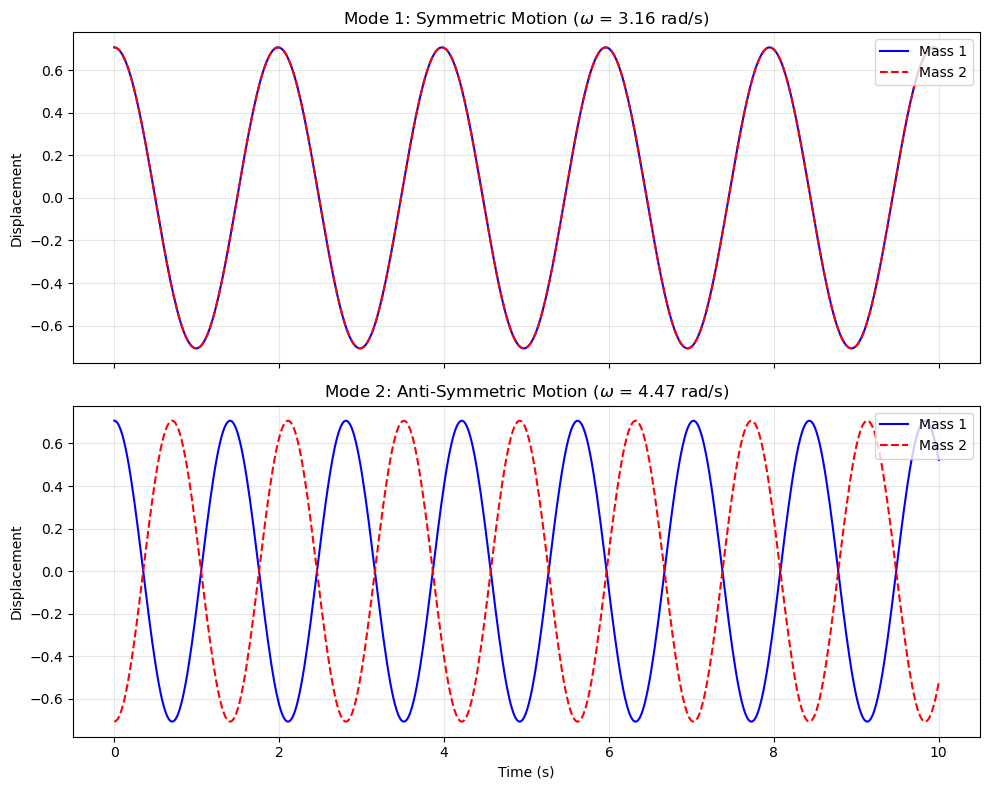

--- PHYSICAL INTERPRETATION ---
Mode 1 (Low Freq: 3.16 rad/s): Both lines move 'In Phase'.
Mode 2 (High Freq: 4.47 rad/s): Lines move 'Out of Phase' (mirrored).


In [4]:
import numpy as np
import matplotlib.pyplot as plt

"""
LINEAR ALGEBRA FOR PHYSICS
Find the frequencies and shapes of motion for two coupled masses.
System: Wall --[k1]-- (m1) --[k2]-- (m2) --[k3]-- Wall
"""

# --- 1. SET UP THE SYSTEM ---
m1, m2 = 1.0, 1.0       # Masses (kg)
k1, k2, k3 = 10.0, 5.0, 10.0 # Spring constants (N/m)

# --- 2. BUILD THE STIFFNESS MATRIX (K) ---
# For a 2-mass system, the matrix looks like:
# [ (k1+k2)/m1 ,   -k2/m1    ]
# [   -k2/m2   , (k2+k3)/m2  ]
K = np.array([
    [(k1 + k2)/m1, -k2/m1],
    [-k2/m2, (k2 + k3)/m2]
])

# --- 3. SOLVE THE EIGENVALUE PROBLEM ---
# evals: The eigenvalues (omega squared)
# evecs: The eigenvectors (The 'Shape' of the motion)
evals, evecs = np.linalg.eig(K)

# --- SORTING ---
# np.linalg.eig returns modes in arbitrary order. 
# We sort them by frequency (eigenvalue) to ensure consistent labeling.
idx = np.argsort(evals)
evals = evals[idx]        # eigen values
evecs = evecs[:, idx]     # eigen vectors   // see previous notes for details of indices

# The natural frequencies (rad/s) are the square roots
omegas = np.sqrt(evals)       # square root of the eigen values ... why? because we're ...?

print("--- PHYSICS ANALYSIS ---")
for i in range(len(omegas)):
    print(f"Mode {i+1}: Frequency = {omegas[i]:.3f} rad/s")
    print(f"       Relative Motion [x1, x2] = {evecs[:, i]}")

# --- 4. CREATE TIME-SERIES DATA ---
t = np.linspace(0, 10, 500)

def get_mode_motion(t, omega, eigenvector):
    # x(t) = Amplitude * cos(omega * t)
    # The eigenvector [A, B] gives the relative amplitude of mass 1 and mass 2
    x1 = eigenvector[0] * np.cos(omega * t)
    x2 = eigenvector[1] * np.cos(omega * t)
    return x1, x2

# --- 5. VISUALIZATION ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# MODE 1 (Symmetric / Lower Frequency)
x1_m1, x2_m1 = get_mode_motion(t, omegas[0], evecs[:, 0])
ax1.plot(t, x1_m1, 'b-', label='Mass 1')
ax1.plot(t, x2_m1, 'r--', label='Mass 2')
ax1.set_title(f"Mode 1: Symmetric Motion ($\omega$ = {omegas[0]:.2f} rad/s)")
ax1.set_ylabel("Displacement")
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# MODE 2 (Anti-Symmetric / Higher Frequency)
x1_m2, x2_m2 = get_mode_motion(t, omegas[1], evecs[:, 1])
ax2.plot(t, x1_m2, 'b-', label='Mass 1')
ax2.plot(t, x2_m2, 'r--', label='Mass 2')
ax2.set_title(f"Mode 2: Anti-Symmetric Motion ($\omega$ = {omegas[1]:.2f} rad/s)")
ax2.set_ylabel("Displacement")
ax2.set_xlabel("Time (s)")
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("--- PHYSICAL INTERPRETATION ---")
print(f"Mode 1 (Low Freq: {omegas[0]:.2f} rad/s): Both lines move 'In Phase'.")
print(f"Mode 2 (High Freq: {omegas[1]:.2f} rad/s): Lines move 'Out of Phase' (mirrored).")

In [5]:
# what if we have 10 masses?
# we would wind up with 10 eigen vectors
# this is a 10by10 matrix
# difficult by hand
# easier by code
# given them all the same spring constant
# exactly the same as problem above, but scaled the problem up
# construct the matrix for this problem we only consider the nearest neighbors
# particular mass pulled to left by its left neighbor and right by its right neighbor
# diagonal component and off diagonal component
# everything further away is treated as zero
# how to know when to consider a mass as zero? taking the immediate next door neighbor is sufficient
# everyone one else can be zero
# we can use shorthand in python ... np.diag (vec, k) easy pz diagonal matrix

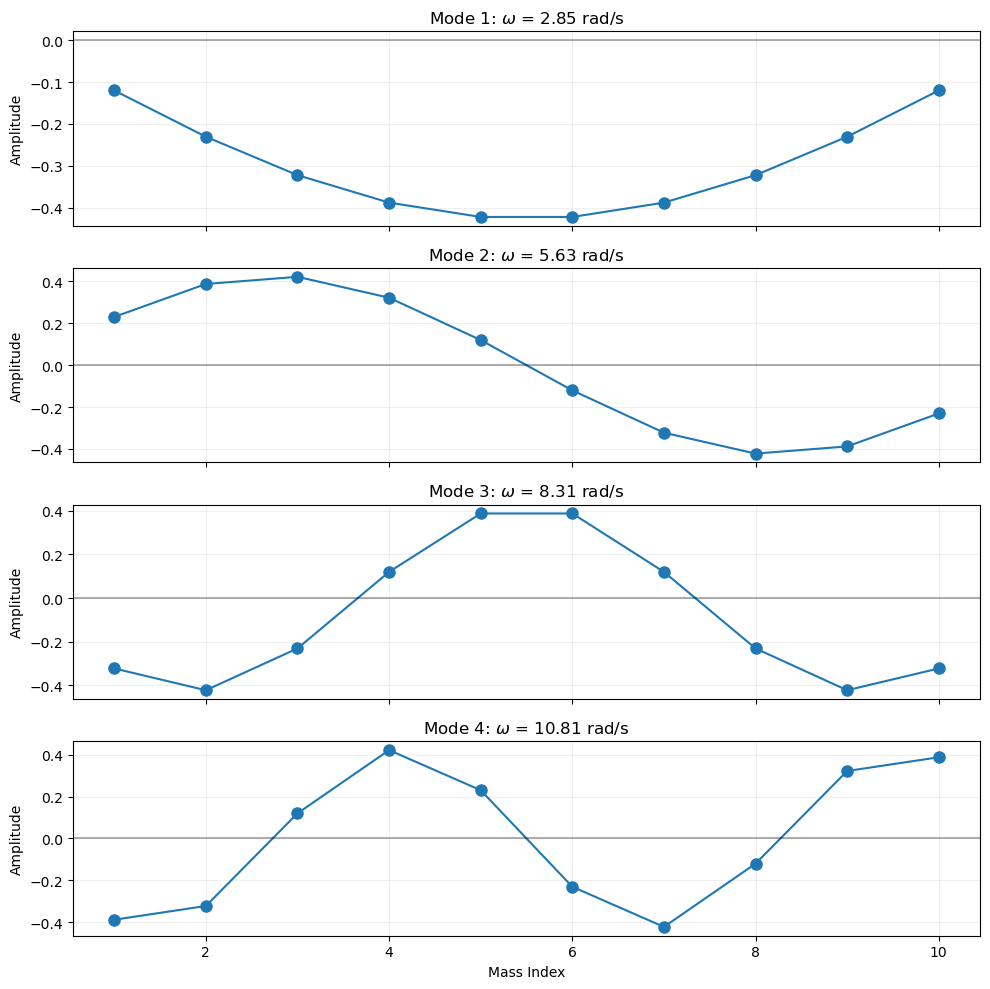

Constructed a 10x10 matrix.
Mode 1 is the fundamental frequency (like a guitar string).
Higher modes have more 'nodes' (crossings of the zero line).


In [6]:
"""
LINEAR ALGEBRA: THE N-MASS CHAIN
Goal: Find the natural frequencies and vibration shapes for a string 
      of N masses connected by springs.
System: Fixed Wall --(k)--(m)--(k)--(m)--(k)-- ... --(k)-- Fixed Wall
"""

# --- 1. SET UP THE SYSTEM ---
N = 10         # Number of masses
m = 1.0        # Mass of each particle (kg)
k = 100.0      # Spring constant (N/m)

# --- 2. BUILD THE DYNAMICAL MATRIX (A) ---
# For a chain, each mass is pulled by its left and right neighbors.
# The diagonal is (k+k)/m = 2k/m
# The off-diagonals are -k/m
diag_val = 2 * k / m
off_diag = -k / m

# Create the tridiagonal matrix using np.diag
# np.diag(vec, k) places the vector on the k-th diagonal
A = np.diag(np.full(N, diag_val)) + \
    np.diag(np.full(N-1, off_diag), k=1) + \
    np.diag(np.full(N-1, off_diag), k=-1)

# --- 3. SOLVE THE EIGENVALUE PROBLEM ---
evals, evecs = np.linalg.eig(A)

# Sort by frequency (low to high)
idx = np.argsort(evals)
omegas = np.sqrt(evals[idx])
evecs = evecs[:, idx]

# --- 4. VISUALIZATION ---
# Let's look at the first 4 "Normal Modes"
fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
x_pos = np.arange(1, N + 1)

for i in range(4):
    ax = axes[i]
    # The i-th eigenvector tells us the displacement of each mass
    mode_shape = evecs[:, i]
    
    # Plot the "Envelope" of the vibration
    ax.plot(x_pos, mode_shape, 'o-', markersize=8, label=f"Mode {i+1}")
    ax.axhline(0, color='black', alpha=0.3)
    ax.set_ylabel("Amplitude")
    ax.set_title(f"Mode {i+1}: $\omega$ = {omegas[i]:.2f} rad/s")
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel("Mass Index")
plt.tight_layout()
plt.show()

print(f"Constructed a {N}x{N} matrix.")
print("Mode 1 is the fundamental frequency (like a guitar string).")
print("Higher modes have more 'nodes' (crossings of the zero line).")

In [7]:
# the frequency mode is lower than the one from the last graph in the last problem
# we have a lowest frequency mode that has no nodes
# what is a node?

In [8]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML  # Required for Jupyter rendering


"""
LONGITUDINAL NORMAL MODES VISUALIZER
Goal: Move away from 'transverse' looking graphs to see actual 
      back-and-forth motion of a coupled mass chain.
"""

# --- ANIMATION SETUP ---
selected_mode = 0  # Change this (0 to 9) to see different harmonics
amplitude = 0.4    

x_eq = np.arange(1, N + 1) * spacing
y_zeros = np.zeros(N)

fig, ax = plt.subplots(figsize=(10, 3))
ax.set_xlim(0, (N + 1) * spacing)
ax.set_ylim(-0.5, 0.5)

# Initialize visual elements
springs, = ax.plot(x_eq, y_zeros, color='gray', lw=1, alpha=0.4, zorder=1)
mass_dots, = ax.plot(x_eq, y_zeros, 'bo', markersize=12, label="Masses", zorder=2)
ax.scatter(x_eq, y_zeros, marker='|', color='red', alpha=0.3, label="Equilibrium")

ax.set_title(f"Longitudinal Mode {selected_mode + 1} ($\omega$ = {omegas[selected_mode]:.2f} rad/s)")
ax.set_xlabel("Physical Position (x)")
ax.get_yaxis().set_visible(False)
ax.legend(loc='upper right')

def update(frame):
    # frame/10.0 provides the time variable 't'
    t = frame * 0.1
    displacements = amplitude * evecs[:, selected_mode] * np.cos(omegas[selected_mode] * t)
    current_x = x_eq + displacements
    
    mass_dots.set_data(current_x, y_zeros)
    springs.set_data(current_x, y_zeros)
    return (mass_dots, springs)

# --- JUPYTER RENDERING ---
# We create the animation object using FuncAnimation
ani = FuncAnimation(fig, update, frames=100, interval=50, blit=True)

# CRITICAL FOR JUPYTER: 
# Instead of plt.show(), we close the plot and display it as JSHTML.
plt.close() 
HTML(ani.to_jshtml())

NameError: name 'spacing' is not defined

## Static Systems: Solving for the Unknown

In many physics problems, you have a set of "Laws" (Kirchhoff, Newton) that relate several unknown quantities. If the relationships are linear, we can always write them as:

$$Ax = b$$

where:

$A$ (The Coefficient Matrix): The "Rules" of the system (Resistances, Angles, Geometry).

$x$ (The Unknown Vector): The things we want to find (Currents, Tensions, Forces).

$b$ (The Source Vector): The "Inputs" (Batteries, Hanging weights).

### Example 1: Kirchhoff’s Loop Rule (Circuits)

Imagine a circuit with three loops. Applying the loop rule ($\sum V = 0$) gives you three equations for three currents ($I_1, I_2, I_3$):

$10I_1 - 2I_2 + 0I_3 = 12$

$-2I_1 + 8I_2 - 4I_3 = 0$

$0I_1 - 4I_2 + 6I_3 = -5$

Write this in matrix form and use x = np.linalg.solve(A, b) to solve the system of equations. 

### Example 2: Static Equilibrium (2D Tension)

A weight ($W$) is hanging from two cables at different angles ($\theta_1, \theta_2$). We need to find the tensions $T_1$ and $T_2$.
The physics says the sum of forces in $x$ and $y$ must be zero:

x-axis: $-T_1 \cos(\theta_1) + T_2 \cos(\theta_2) = 0$

y-axis: $T_1 \sin(\theta_1) + T_2 \sin(\theta_2) = W$

Construct a 2x2 matrix and solve. 

In [ ]:
# Homework is Example 1 and Example 2

In [24]:
# Example 1

In [25]:
# create an array
A = np.array([
    [10, -2, 0],
    [-2, 8, -4],
    [0, -4, 6]
])

# create an array
b = np.array([12, 0, -5])

x = np.linalg.solve(A, b)

print("[I1, I2, I3]:", x)

[I1, I2, I3]: [ 1.16216216 -0.18918919 -0.95945946]


In [26]:
# Example 2

In [32]:
# define variables ... use 30 and 45 degrees
theta1 = np.radians(30)
theta2 = np.radians(45)
W = 100                   # Newtons

# make an array for A
A = np.array([
    [-np.cos(theta1), np.cos(theta2)],
    [np.sin(theta1), np.sin(theta2)]
])

# make an array for b
b = np.array([0, W])

# look for unknown tensions
x = np.linalg.solve(A, b)

print("Tensions: [T1,T2]", x)

Tensions: [T1,T2] [73.20508076 89.65754722]
